$\Huge \text{SESSION-4}$  
●	Monte Carlo Methods  
●	Temporal Difference (TD) Learning  
●	Q-Learning  
●	Function Approximation  

In this notebook, I will be solving a well known reinforcement learning problem, namely "Taxi-v3", readily importable from gymnasium, using Q-Learning algorithm.  
References: https://gymnasium.farama.org/environments/toy_text/taxi/


$\huge \text{Problem Statement}$  
The environment is a 5x5 grid with 4 designated spots colored red, yellow, blude and green.  
The passenger will be at one of these spots, with a predefined destination which itself will be one of these spots.  
The taxi (that will inititally spawn at the centre of the grid) must go to the "pick-up" spot and drop them off at the destination.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [ ]:
env = gym.make("Taxi-v3", render_mode='rgb_array')
n_states = env.observation_space.n
n_actions = env.action_space.n

For this particular setting, there are 25x4x5 states (25 grid cells, 4  
destination, 5 location of the passenger - including the state when the  
passenger is in the taxi), and 6 actions (up, down, left, right, pick up, drop).

Rewards for this setting:  
-1 per step unless other reward is triggered.  
+20 delivering passenger.  
-10 executing “pickup” and “drop-off” actions illegally.

HYPERPARAMETERS

In [ ]:
alpha = 0.7
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 0.995
episodes = 5000
max_steps = 100

In [ ]:
Q = np.zeros((n_states, n_actions))

TRAINING

In [ ]:
rewards_per_episode = []

for ep in range(episodes):
  state, _ = env.reset()
  total_reward = 0

  for step in range(max_steps):
    if np.random.uniform(0,1) < epsilon:
      action = env.action_space.sample()
    else:
      action = np.argmax(Q[state, :])


    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    Q[state, action] += alpha*(
        reward + gamma * np.max(Q[next_state, :]) - Q[state, action]
    )

    state = next_state
    total_reward += reward

    if done:
      break

  epsilon = max(epsilon_min, epsilon * epsilon_decay)
  rewards_per_episode.append(total_reward)

In [ ]:
n_eval_episodes = 100
total_eval_rewards = 0

for _ in range(n_eval_episodes):
  state, _ = env.reset()
  done = False
  while not done:
    action = np.argmax(Q[state, :])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_eval_rewards += reward

print(f"Average reward over {n_eval_episodes} eval episodes: {total_eval_rewards/n_eval_episodes:.2f}")

Average reward over 100 eval episodes: 7.97


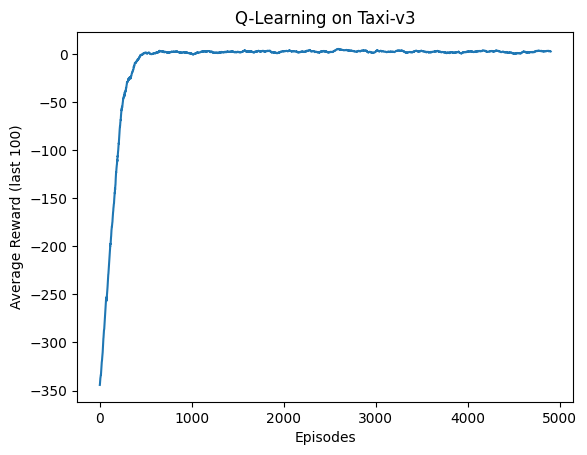

In [ ]:
plt.plot(np.convolve(rewards_per_episode, np.ones(100)/100, mode = 'valid'))
plt.xlabel("Episodes")
plt.ylabel("Average Reward (last 100)")
plt.title("Q-Learning on Taxi-v3")
plt.show()

At first, the reward is highly negative that indicates that the agent is making illegal and very inefficient moves.  
But as more episodes take place, the reward increases, indicative of the agent learning.  
Around the 1000th episode, the reward reaches the maximum possible value.

EVALUATING

In [ ]:
frames = []

state, _ = env.reset()
done = False
while not done:
    frames.append(env.render())
    action = np.argmax(Q[state, :])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
frames.append(env.render())


LOADING THE ANIMATION

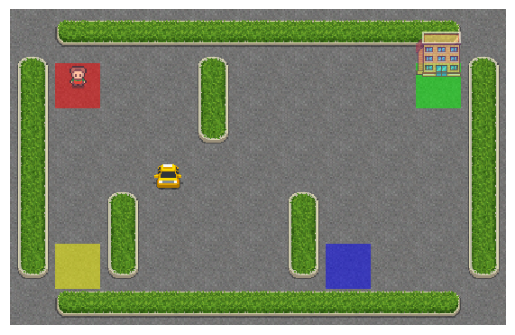

In [ ]:
fig, ax = plt.subplots()
plt.axis("off")

def update(frame):
    ax.imshow(frame)
    return ax.images

ani = animation.FuncAnimation(fig, update, frames=frames, interval=100, repeat=False)


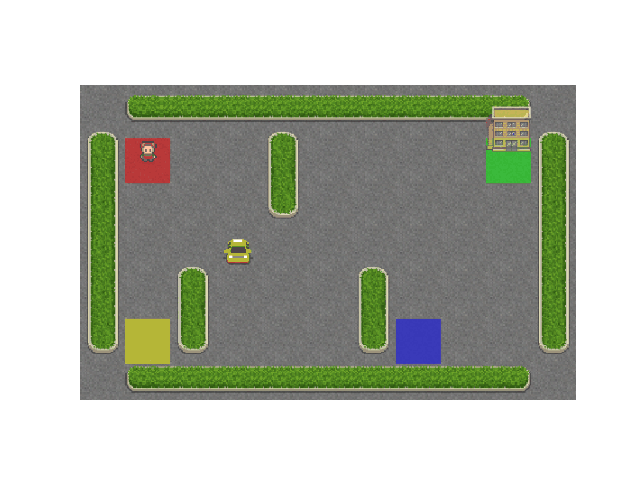

In [ ]:
from IPython.display import HTML
import base64
ani.save('taxi_animation.gif', writer='pillow')
plt.close(fig)


with open('taxi_animation.gif', 'rb') as f:
    display(HTML(f'<img src="data:image/gif;base64,{base64.b64encode(f.read()).decode()}"/>'))